In [1]:
# ================================================================
# CELL 1 — SETUP, UNIFIED DATASET, MODEL
# ================================================================
import numpy as np
from pathlib import Path
from PIL import Image
import random
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

# ----------------- Config -----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

DATA_ROOT  = Path("data")   # contains BMCC, hublast, Jurkat, prhu, J558L
MASK_ROOT  = Path("masks")  # same subfolders as data

IMG_SIZE   = 384
BATCH_SIZE = 1
NUM_EPOCHS = 60
LR         = 3e-5
COLOR_LOSS_WEIGHT = 3.0


# ================================================================
# Helper: find best matching mask for an image
# ================================================================
def find_mask_for_image(img_path: Path, mask_root: Path) -> Path:
    """
    Search recursively in mask_root for a file whose stem contains
    the image stem (case-insensitive). Works for names like:
    BMMC_35.tif  ->  BMMC_35.tif_segmentation.tifnomalized.tif
    """
    stem = img_path.stem.lower()
    candidates = list(mask_root.rglob("*.tif")) + list(mask_root.rglob("*.png")) + list(mask_root.rglob("*.jpg"))
    for m in candidates:
        if stem in m.stem.lower():
            return m
    raise FileNotFoundError(f"No mask found for image: {img_path}")


# ================================================================
# Unified TEM dataset (all 5 cell types)
# ================================================================
class MixedTEMDataset(Dataset):
    def __init__(self, data_root, mask_root, img_size=384, augment=True):
        self.img_paths = sorted(
            list(Path(data_root).rglob("*.tif")) +
            list(Path(data_root).rglob("*.png")) +
            list(Path(data_root).rglob("*.jpg"))
        )
        self.mask_root = Path(mask_root)
        self.img_size  = img_size
        self.augment   = augment

        print(f"Found {len(self.img_paths)} images across all cell types.")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        mask_path = find_mask_for_image(img_path, self.mask_root)

        # 1) Load raw TEM image
        img = Image.open(img_path).convert("L")
        img = np.array(img, dtype=np.float32)

        # 2) Load mask & remap classes 85/170/255 -> 0/1/2
        mask = Image.open(mask_path).convert("L")
        mask = np.array(mask, dtype=np.int64)
        mask = np.where(mask == 85, 0, mask)
        mask = np.where(mask == 170, 1, mask)
        mask = np.where(mask == 255, 2, mask)
        mask = mask.astype(np.int64)

        # 3) Crop around cell (tight margin)
        ys, xs = np.where(mask > 0)
        if len(xs) > 0:
            ymin, ymax = ys.min(), ys.max()
            xmin, xmax = xs.min(), xs.max()

            margin = 10
            ymin = max(0, ymin - margin)
            ymax = min(mask.shape[0], ymax + margin)
            xmin = max(0, xmin - margin)
            xmax = min(mask.shape[1], xmax + margin)

            img = img[ymin:ymax, xmin:xmax]
            mask = mask[ymin:ymax, xmin:xmax]

        # 4) Resize
        img = Image.fromarray(img.astype(np.uint8)).resize(
            (self.img_size, self.img_size), Image.BILINEAR
        )
        mask = Image.fromarray(mask.astype(np.uint8)).resize(
            (self.img_size, self.img_size), Image.NEAREST
        )

        img = np.array(img, dtype=np.float32) / 255.0
        mask = np.array(mask, dtype=np.int64)

        # 5) Augmentation (no negative strides)
        if self.augment:
            if random.random() < 0.5:
                img  = np.fliplr(img).copy()
                mask = np.fliplr(mask).copy()
            if random.random() < 0.5:
                img  = np.flipud(img).copy()
                mask = np.flipud(mask).copy()

        # 6) To tensors
        img_t = torch.from_numpy(img).unsqueeze(0)  # (1,H,W)
        mask_t = torch.from_numpy(mask)             # (H,W)

        return img_t, mask_t


# ================================================================
# Palette & helper
# ================================================================
palette = torch.tensor([
    [0.0, 0.0, 0.0],   # background
    [0.9, 0.4, 0.0],   # cytoplasm (soft orange)
    [0.0, 0.4, 0.9],   # nucleus   (soft blue)
], dtype=torch.float32)

def mask_to_color(mask_batch, palette):
    # mask_batch: (B,H,W)
    col = palette.to(mask_batch.device)[mask_batch]    # (B,H,W,3)
    return col.permute(0,3,1,2).contiguous()           # (B,3,H,W)


# ================================================================
# Dice loss
# ================================================================
def dice_loss(logits, targets, eps=1e-6):
    probs = torch.softmax(logits, dim=1)
    C = probs.shape[1]
    total = 0.0
    for c in range(C):
        p = probs[:, c]           # (B,H,W)
        t = (targets == c).float()
        inter = (p * t).sum()
        union = p.sum() + t.sum() + eps
        total += 1 - (2 * inter / union)
    return total / C


# ================================================================
# 5-level U-Net (VRAM-safe: base 32)
# ================================================================
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(True),
        )
    def forward(self, x): return self.block(x)


class UNet5(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        f = [32, 64, 128, 256, 512]

        # Down
        self.dc1 = DoubleConv(1, f[0]); self.p1 = nn.MaxPool2d(2)
        self.dc2 = DoubleConv(f[0], f[1]); self.p2 = nn.MaxPool2d(2)
        self.dc3 = DoubleConv(f[1], f[2]); self.p3 = nn.MaxPool2d(2)
        self.dc4 = DoubleConv(f[2], f[3]); self.p4 = nn.MaxPool2d(2)
        self.dc5 = DoubleConv(f[3], f[4]); self.p5 = nn.MaxPool2d(2)

        # Bottleneck
        self.dc6 = DoubleConv(f[4], f[4]*2)

        # Up
        self.up5 = nn.ConvTranspose2d(f[4]*2, f[4], 2, 2)
        self.uc5 = DoubleConv(f[4]+f[4], f[4])

        self.up4 = nn.ConvTranspose2d(f[4], f[3], 2, 2)
        self.uc4 = DoubleConv(f[3]+f[3], f[3])

        self.up3 = nn.ConvTranspose2d(f[3], f[2], 2, 2)
        self.uc3 = DoubleConv(f[2]+f[2], f[2])

        self.up2 = nn.ConvTranspose2d(f[2], f[1], 2, 2)
        self.uc2 = DoubleConv(f[1]+f[1], f[1])

        self.up1 = nn.ConvTranspose2d(f[1], f[0], 2, 2)
        self.uc1 = DoubleConv(f[0]+f[0], f[0])

        # Heads
        self.seg_head = nn.Conv2d(f[0], n_classes, 1)
        self.col_head = nn.Sequential(
            nn.Conv2d(f[0], 3, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        d1 = self.dc1(x)
        d2 = self.dc2(self.p1(d1))
        d3 = self.dc3(self.p2(d2))
        d4 = self.dc4(self.p3(d3))
        d5 = self.dc5(self.p4(d4))
        bn = self.dc6(self.p5(d5))

        u5 = self.uc5(torch.cat([self.up5(bn), d5], dim=1))
        u4 = self.uc4(torch.cat([self.up4(u5), d4], dim=1))
        u3 = self.uc3(torch.cat([self.up3(u4), d3], dim=1))
        u2 = self.uc2(torch.cat([self.up2(u3), d2], dim=1))
        u1 = self.uc1(torch.cat([self.up1(u2), d1], dim=1))

        seg = self.seg_head(u1)
        col = self.col_head(u1)
        return seg, col


# ================================================================
# Instantiate dataset, loaders, model, losses, optimizer
# ================================================================
dataset = MixedTEMDataset(DATA_ROOT, MASK_ROOT, IMG_SIZE, augment=True)

train_len = int(0.85 * len(dataset))
val_len   = len(dataset) - train_len
train_ds, val_ds = random_split(dataset, [train_len, val_len])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model = UNet5().to(DEVICE)

# Class-balanced CE
class_weights = torch.tensor([0.1, 1.0, 2.0], dtype=torch.float32).to(DEVICE)
ce_loss = nn.CrossEntropyLoss(weight=class_weights)

# Smooth L1 for color
col_loss_fn = nn.SmoothL1Loss(beta=0.05)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)


Using device: cuda
Found 523 images across all cell types.


In [17]:
# ================================================================
# CELL 2 — TRAINING
# ================================================================
def train_epoch(epoch):
    model.train()
    seg_tot, col_tot = 0.0, 0.0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()

        seg_logits, col_pred = model(imgs)

        seg_loss_ce   = ce_loss(seg_logits, masks)
        seg_loss_dice = dice_loss(seg_logits, masks)
        seg_loss = 0.7 * seg_loss_ce + 0.3 * seg_loss_dice

        col_target = mask_to_color(masks, palette)
        col_loss   = col_loss_fn(col_pred, col_target)

        loss = seg_loss + COLOR_LOSS_WEIGHT * col_loss
        loss.backward()
        optimizer.step()

        seg_tot += seg_loss.item()
        col_tot += col_loss.item()

    print(f"[Train {epoch}] Seg={seg_tot/len(train_loader):.4f}  Col={col_tot/len(train_loader):.4f}")


@torch.no_grad()
def validate(epoch):
    model.eval()
    seg_tot, col_tot = 0.0, 0.0

    for imgs, masks in val_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        seg_logits, col_pred = model(imgs)

        seg_loss_ce   = ce_loss(seg_logits, masks)
        seg_loss_dice = dice_loss(seg_logits, masks)
        seg_loss = 0.7 * seg_loss_ce + 0.3 * seg_loss_dice

        col_loss = col_loss_fn(col_pred, mask_to_color(masks, palette))

        seg_tot += seg_loss.item()
        col_tot += col_loss.item()

    print(f"[Val   {epoch}] Seg={seg_tot/len(val_loader):.4f}  Col={col_tot/len(val_loader):.4f}")
    return col_tot / len(val_loader)


best_val = float("inf")
for epoch in range(1, NUM_EPOCHS + 1):
    train_epoch(epoch)
    val_col = validate(epoch)

    if val_col < best_val:
        best_val = val_col
        torch.save(model.state_dict(), "best_baseline.pth")
        print("🔥 Saved new best model")


[Train 1] Seg=0.1850  Col=0.0307
[Val   1] Seg=0.3043  Col=0.0454
🔥 Saved new best model
[Train 2] Seg=0.1774  Col=0.0297
[Val   2] Seg=0.2998  Col=0.0440
🔥 Saved new best model
[Train 3] Seg=0.1595  Col=0.0271
[Val   3] Seg=0.3156  Col=0.0441
[Train 4] Seg=0.1738  Col=0.0292
[Val   4] Seg=0.3226  Col=0.0486
[Train 5] Seg=0.1691  Col=0.0280
[Val   5] Seg=0.2948  Col=0.0438
🔥 Saved new best model
[Train 6] Seg=0.1667  Col=0.0279
[Val   6] Seg=0.3003  Col=0.0434
🔥 Saved new best model
[Train 7] Seg=0.1473  Col=0.0253
[Val   7] Seg=0.3367  Col=0.0460
[Train 8] Seg=0.1511  Col=0.0256
[Val   8] Seg=0.3225  Col=0.0476
[Train 9] Seg=0.1541  Col=0.0262
[Val   9] Seg=0.3004  Col=0.0418
🔥 Saved new best model
[Train 10] Seg=0.1515  Col=0.0256
[Val   10] Seg=0.3600  Col=0.0478
[Train 11] Seg=0.1472  Col=0.0249
[Val   11] Seg=0.3571  Col=0.0468
[Train 12] Seg=0.1354  Col=0.0229
[Val   12] Seg=0.3288  Col=0.0440
[Train 13] Seg=0.1365  Col=0.0229
[Val   13] Seg=0.3254  Col=0.0487
[Train 14] Seg=0.14

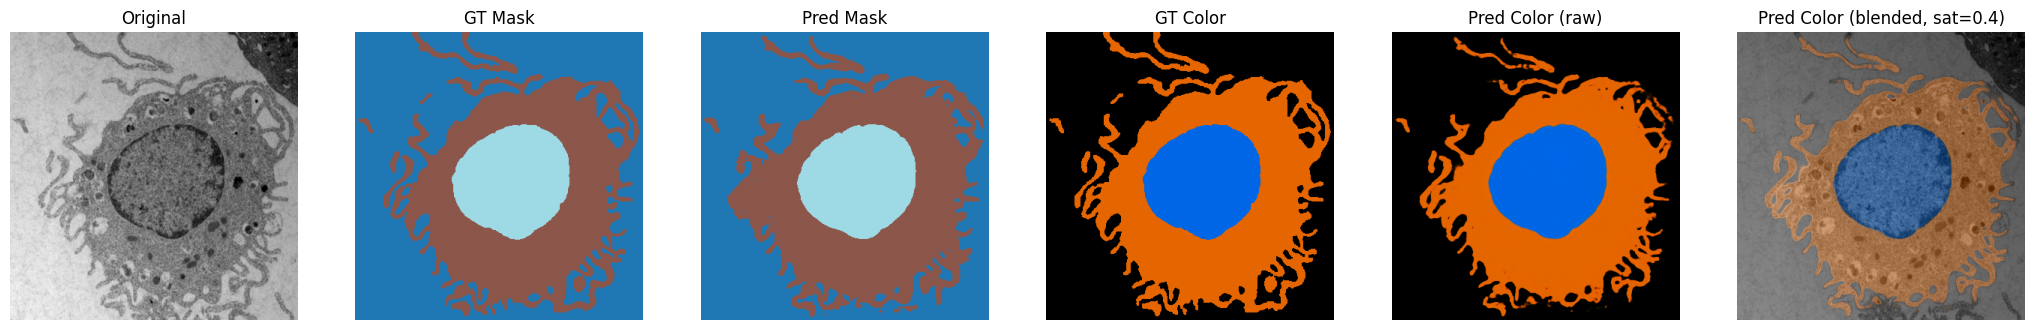

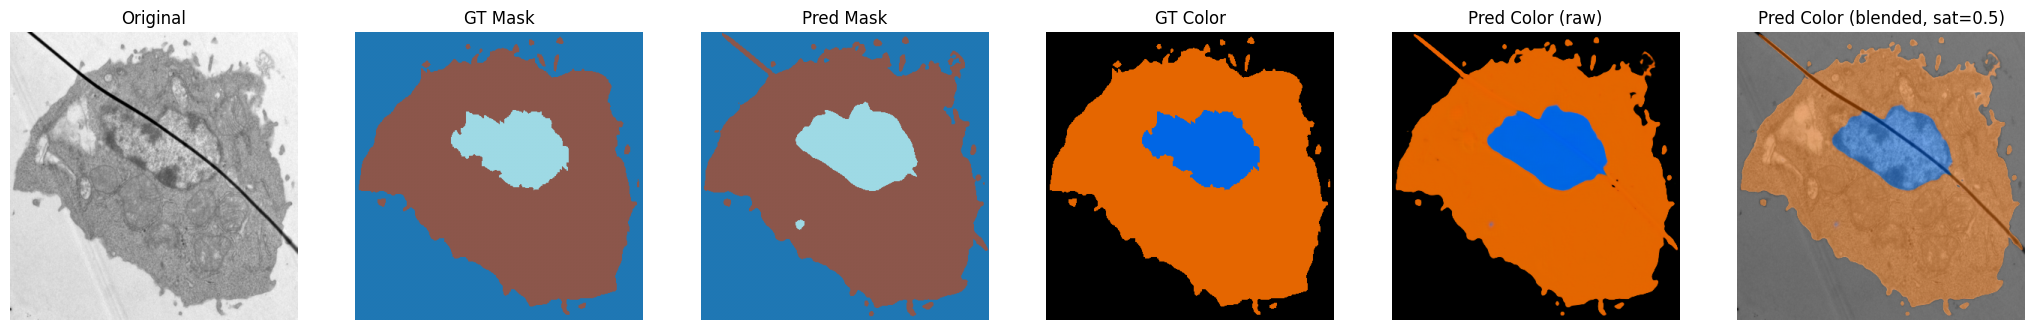

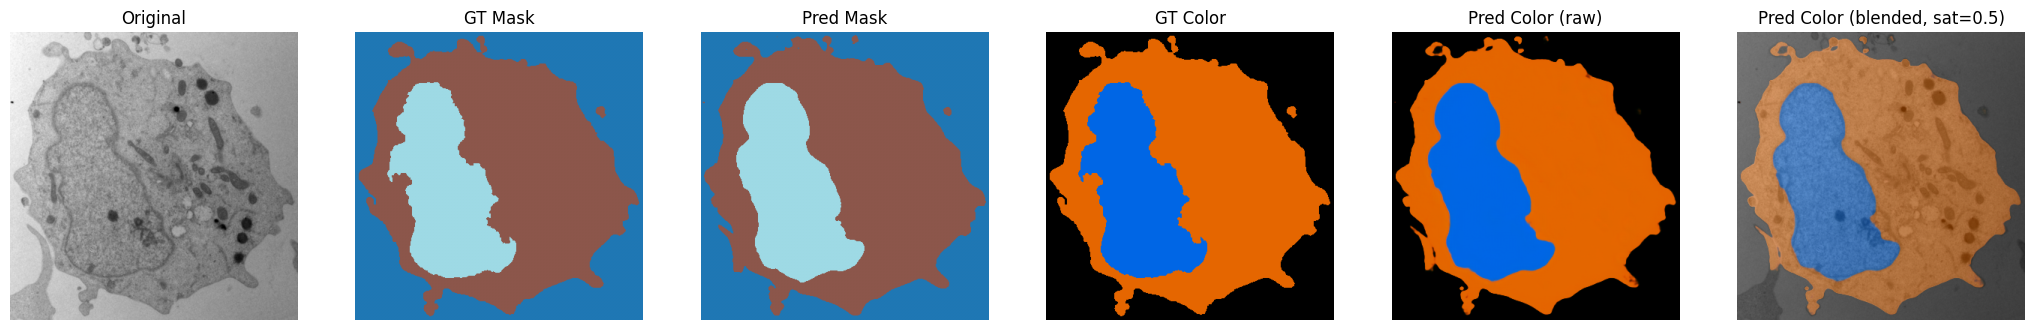

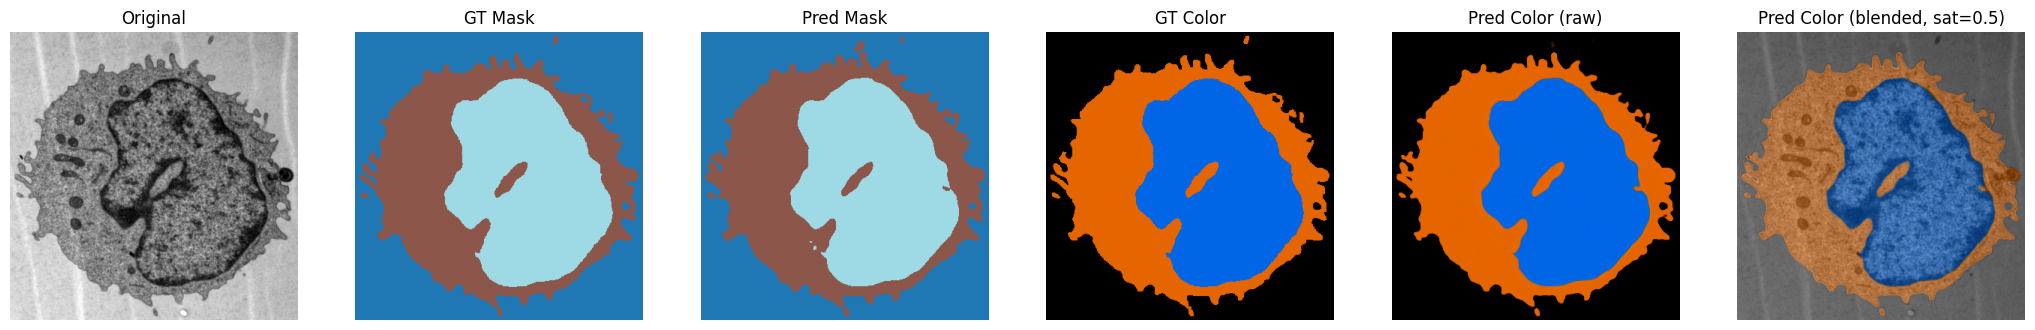

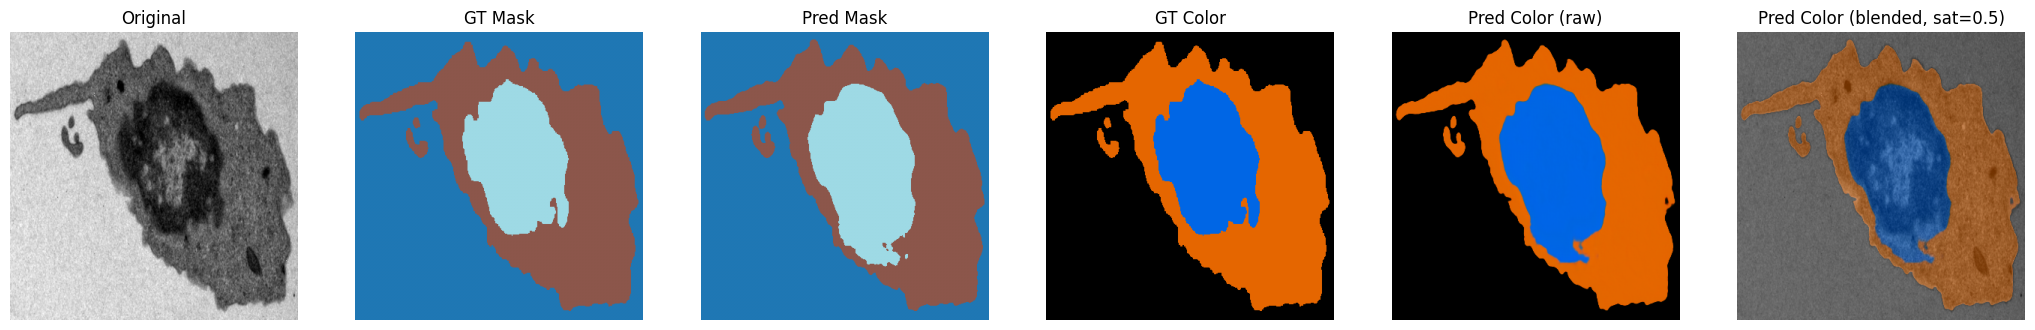

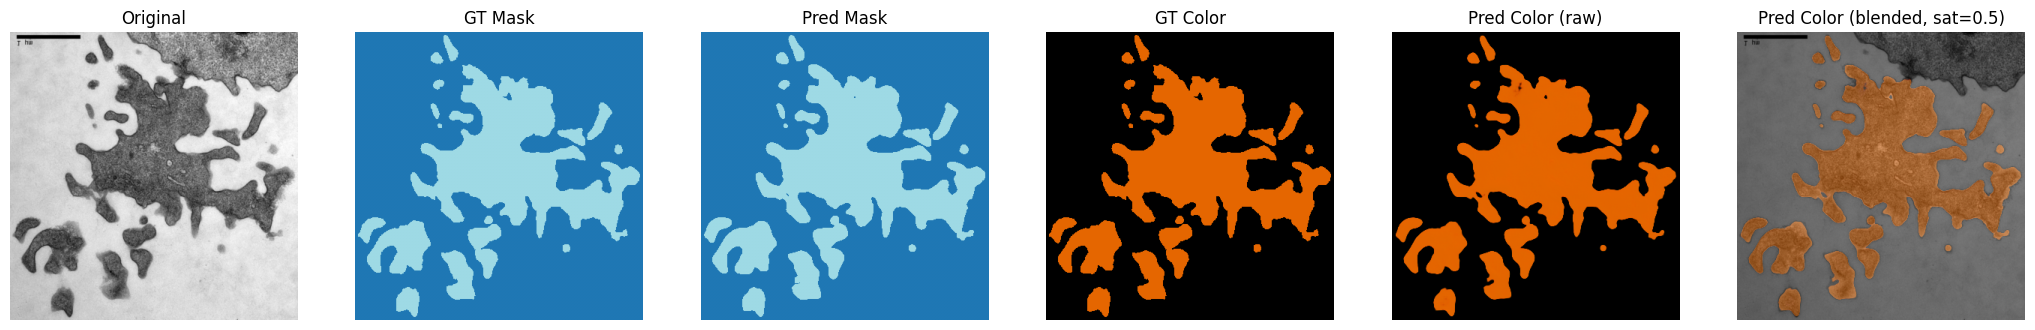

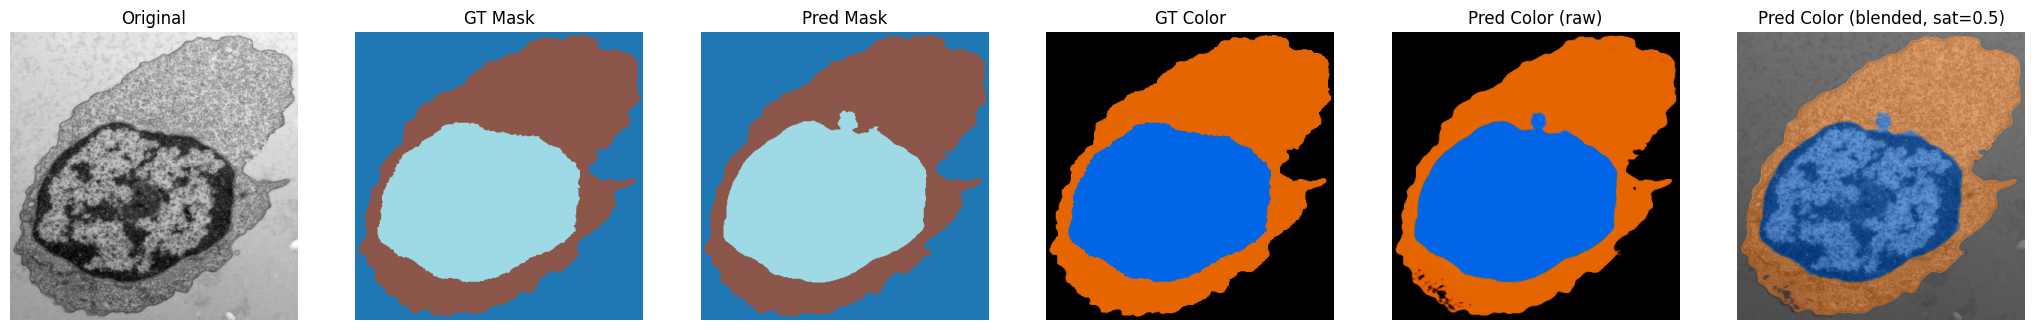

In [26]:
# ================================================================
# CELL 3 — INFERENCE WITH TEXTURE-PRESERVING COLOR BLENDING
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import torch

def blend_color_with_texture(gray, color, sat=0.6):
    """
    gray:  (H,W) float32 0-1   (original image)
    color: (H,W,3) float32 0-1 (predicted pseudo-color)
    sat:   blending strength (0.0–1.0)
    """
    gray_rgb = np.stack([gray, gray, gray], axis=-1)
    return (1 - sat) * gray_rgb + sat * color


@torch.no_grad()
def visualize(idx=0, sat=0.6):
    """
    Visualize: original, GT mask, Pred mask, GT color, Pred color (blended).
    """
    model.eval()

    img, mask = dataset[idx]                 # img: (1,H,W)
    gray_np = img.squeeze(0).numpy()         # (H,W)
    img_t = img.unsqueeze(0).to(DEVICE)      # (1,1,H,W)

    seg_logits, col_pred = model(img_t)

    pred_mask = torch.argmax(seg_logits, dim=1).squeeze(0).cpu().numpy()
    pred_color = col_pred.squeeze(0).permute(1,2,0).cpu().numpy()

    # Ground truth color
    gt_color = mask_to_color(mask.unsqueeze(0), palette)
    gt_color_np = gt_color.squeeze(0).permute(1,2,0).cpu().numpy()

    # NEW: texture-preserving blended output
    blended_color = blend_color_with_texture(gray_np, pred_color, sat=sat)

    # ---- Plot everything ----
    fig, ax = plt.subplots(1,6, figsize=(26,5))
    ax[0].imshow(gray_np, cmap="gray"); ax[0].set_title("Original"); ax[0].axis("off")
    ax[1].imshow(mask, cmap="tab20"); ax[1].set_title("GT Mask"); ax[1].axis("off")
    ax[2].imshow(pred_mask, cmap="tab20"); ax[2].set_title("Pred Mask"); ax[2].axis("off")
    ax[3].imshow(gt_color_np); ax[3].set_title("GT Color"); ax[3].axis("off")
    ax[4].imshow(pred_color); ax[4].set_title("Pred Color (raw)"); ax[4].axis("off")
    ax[5].imshow(blended_color); ax[5].set_title(f"Pred Color (blended, sat={sat})"); ax[5].axis("off")
    plt.show()


# Example
visualize(37, sat=0.4)
visualize(96, sat=0.5)
visualize(175, sat=0.5)
visualize(297, sat=0.5)
visualize(365, sat=0.5)
visualize(457, sat=0.5)
visualize(512, sat=0.5)



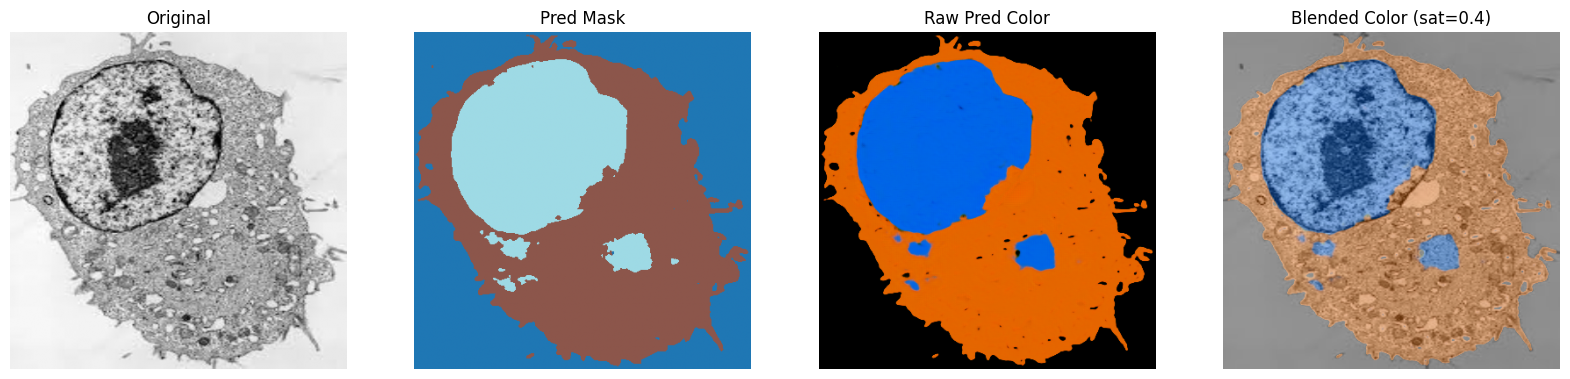

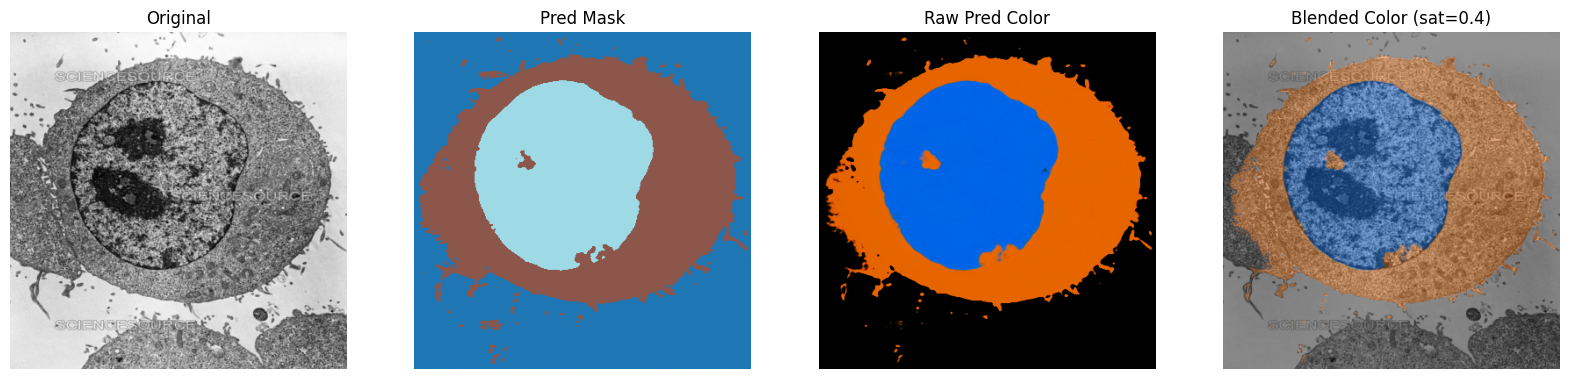

In [25]:
# ================================================================
# INFERENCE ON ANY IMAGE (img.jpg/png/jpeg/tif) WITH TEXTURE-PRESERVING COLOR
# ================================================================
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path


def blend_color_with_texture(gray, color, sat=0.6):
    """
    gray:  (H,W) float 0-1   original grayscale (texture source)
    color: (H,W,3) float 0-1 model's predicted RGB
    sat:   color strength
    """
    gray_rgb = np.stack([gray, gray, gray], axis=-1)
    return (1 - sat) * gray_rgb + sat * color


def load_image_for_inference(filename, img_size=384, auto_crop=True):
    """
    Loads image from same folder as notebook.
    Preprocesses exactly like training images.
    """
    path = Path(filename)
    if not path.exists():
        raise FileNotFoundError(f"File '{filename}' not found.")

    # 1) load grayscale
    img = Image.open(path).convert("L")
    img = np.array(img, dtype=np.float32)

    # ----------------------------
    # 2) optional auto-crop
    # ----------------------------
    if auto_crop:
        thr = np.percentile(img, 50)
        mask_guess = img < thr

        ys, xs = np.where(mask_guess)
        if len(xs) > 0:
            ymin, ymax = ys.min(), ys.max()
            xmin, xmax = xs.min(), xs.max()
            margin = 10

            ymin = max(0, ymin - margin)
            ymax = min(img.shape[0], ymax + margin)
            xmin = max(0, xmin - margin)
            xmax = min(img.shape[1], xmax + margin)

            img = img[ymin:ymax, xmin:xmax]

    # ----------------------------
    # 3) resize
    # ----------------------------
    img_resized = Image.fromarray(img.astype(np.uint8)).resize(
        (img_size, img_size), Image.BILINEAR
    )
    img_norm = np.array(img_resized, dtype=np.float32) / 255.0

    # ----------------------------
    # 4) to tensor
    # ----------------------------
    img_tensor = torch.from_numpy(img_norm).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

    return img_norm, img_tensor.to(DEVICE)


@torch.no_grad()
def predict_image(filename, sat=0.6):
    """
    Run model on a raw TEM image file (jpg/png/jpeg/tif)
    and generate segmentation + blended color.
    """
    model.eval()

    gray_np, img_t = load_image_for_inference(filename, img_size=IMG_SIZE)

    seg_logits, col_pred = model(img_t)

    # segmentation output
    pred_mask = torch.argmax(seg_logits, dim=1).squeeze(0).cpu().numpy()

    # predicted color
    pred_color = col_pred.squeeze(0).permute(1,2,0).cpu().numpy()

    # blended color output (BEST LOOKING)
    blended = blend_color_with_texture(gray_np, pred_color, sat=sat)

    # ---- PLOT ----
    fig, ax = plt.subplots(1,4, figsize=(20,5))
    ax[0].imshow(gray_np, cmap='gray'); ax[0].set_title("Original"); ax[0].axis("off")
    ax[1].imshow(pred_mask, cmap='tab20'); ax[1].set_title("Pred Mask"); ax[1].axis("off")
    ax[2].imshow(pred_color); ax[2].set_title("Raw Pred Color"); ax[2].axis("off")
    ax[3].imshow(blended); ax[3].set_title(f"Blended Color (sat={sat})"); ax[3].axis("off")
    plt.show()


# ============================
# Example Usage:
# ============================
# predict_image("img.jpg", sat=0.6)
# predict_image("example.png", sat=0.8)
predict_image("img.jpeg", sat=0.4)
predict_image("img2.jpg", sat=0.4)
